# **Временные ряды Прогноз заказов такси**

**Цель:** построение модели предсказания количества заказов такси на следующий час.

**Задача:** прогноз количества заказов такси на следующий час.

Ход исследования:
1. Загрузка данных
2. Анализ данных
3. Обучение моделей
4. Анализ моделей
5. Общий вывод

In [1]:
!pip install -Uq scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import os
import lightgbm

from statsmodels.tsa.seasonal import seasonal_decompose
from time import time

# импорт моделей
from catboost import CatBoostRegressor 
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor 
from sklearn.dummy import DummyRegressor

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    TimeSeriesSplit
)

# импорт метрик
from sklearn.metrics import mean_squared_error

#sns.set(rc={"figure.figsize":(16,7)})
plt.rcParams["figure.figsize"] = (16,7)

## Загрузка данных

Загружаем данные, устанавливаем индекс таблицы, равный столбцу *datetime*, сортируем по индексу.

In [3]:
# чтение файла с данными и сохранение в переменную 
#try:
#    taxi = pd.read_csv('/datasets/taxi.csv', parse_dates=[0], index_col=[0])
#except:
#    taxi = pd.read_csv('https://code.s3.yandex.net/datasets/taxi.csv', parse_dates=[0], index_col=[0])

In [4]:
# скачивание и чтение файла, сохранение в переменную
pth_1 = 'taxi.csv'
pth_2 = '/datasets/taxi.csv'

if os.path.exists(pth_1):
    taxi = pd.read_csv(pth_1, parse_dates=[0], index_col=[0])
elif os.path.exists(pth_2):
    taxi = pd.read_csv(pth_2, parse_dates=[0], index_col=[0])
else:
    print('Something is wrong')

In [5]:
taxi.head(3)

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28


In [6]:
taxi.sort_index(inplace=True)

In [7]:
taxi.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


In [9]:
taxi.index.is_monotonic_increasing

True

In [10]:
# ресемплирование по одному часу
taxi = taxi.resample('1h').sum()
taxi.head(3)

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71


**Вывод**

Загружены данные, индексом таблицы сделали столбец *datetime*, индекс отсортирован по возрастанию даты, сделано ресемплирование по одному часу, данные расположены в хронологическом порядке.

## Анализ данных

In [13]:
taxi.describe()

,num_orders
count,4416.000000
mean,84.422781
std,45.023853
min,0.000000
25%,54.000000
50%,78.000000
75%,107.000000
max,462.000000


Минимальное количество заказов 0 максимальное 462.

In [14]:
print(taxi.index.min(), taxi.index.max())

2018-03-01 00:00:00 2018-08-31 23:00:00


Добавим столбец скользящего среднего *rolling_mean* с размером окна равным 24 (сутки)

In [15]:
taxi['rolling_mean'] = taxi['num_orders'].rolling(24).mean()

Добавим столбец скользящего стандартного отклонения с размером окна равным 24 (сутки)

In [16]:
taxi['std'] = taxi['num_orders'].rolling(24).std()

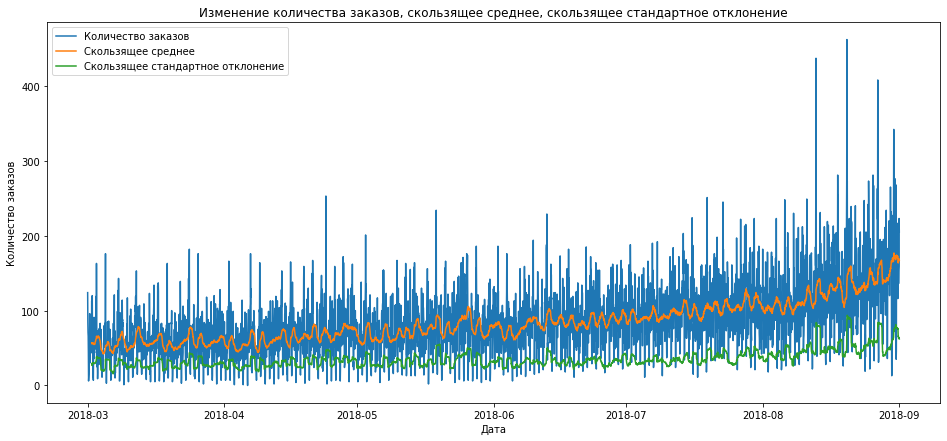

In [17]:
#taxi.plot();
sns.lineplot(data=taxi, x=taxi.index, y='num_orders')
sns.lineplot(data=taxi, x=taxi.index, y='rolling_mean')
sns.lineplot(data=taxi, x=taxi.index, y='std')\
    .set(title='Изменение количества заказов, скользящее среднее, скользящее стандартное отклонение',
     xlabel='Дата',
     ylabel='Количество заказов')
plt.legend(['Количество заказов','Скользящее среднее','Скользящее стандартное отклонение']);

Посмотрим график с ресемплированием по 1 дню.

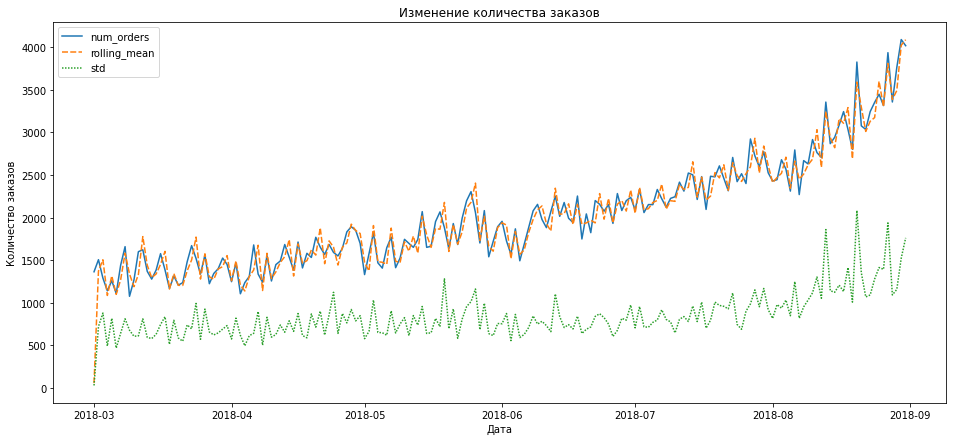

In [18]:
sns.lineplot(data=taxi.resample('1D').sum())\
.set(title='Изменение количества заказов',
     xlabel='Дата',
     ylabel='Количество заказов');

Увеличивается количество заказов. Скользящее среднее и скользящее стандартное отклонение со временем увеличиваются, значит временной ряд не является стационарным.

Тренды и сезонность

In [19]:
decomposed = seasonal_decompose(taxi['num_orders'])

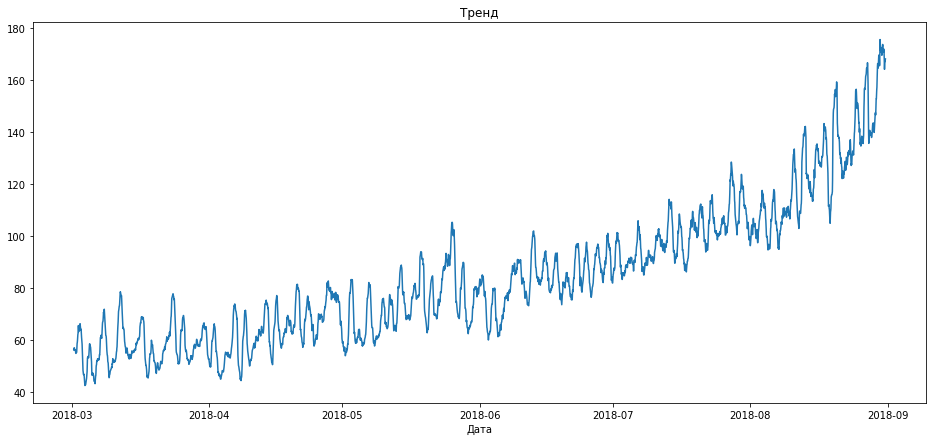

In [21]:
sns.lineplot(data=decomposed.trend)\
.set(title='Тренд',
     xlabel='Дата',
     ylabel='');

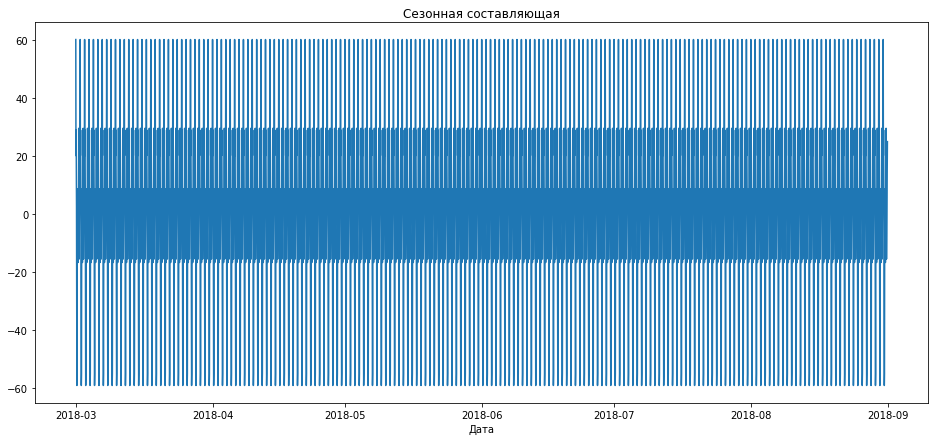

In [22]:
sns.lineplot(data=decomposed.seasonal)\
.set(title='Сезонная составляющая',
     xlabel='Дата',
     ylabel='');

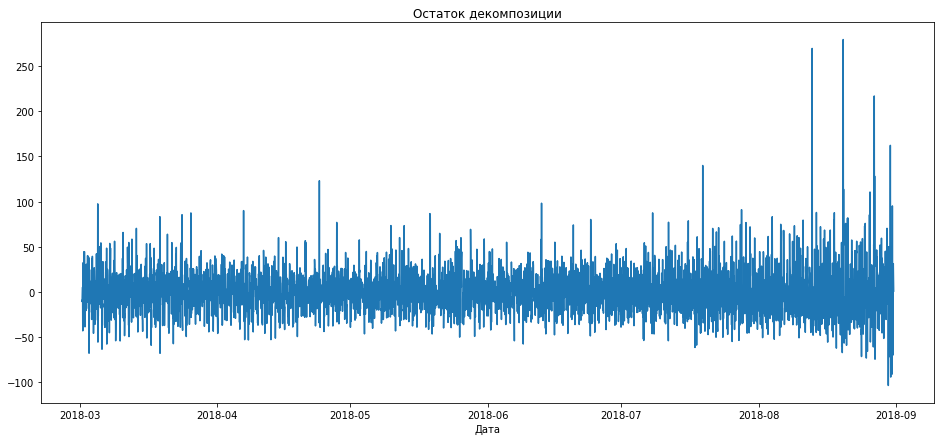

In [23]:
sns.lineplot(data=decomposed.resid)\
.set(title='Остаток декомпозиции',
     xlabel='Дата',
     ylabel='');

График имеет восходящий тренд. Летом заказов больше, чем весной. Сезонность присутвует. Рассмотрим ближе.

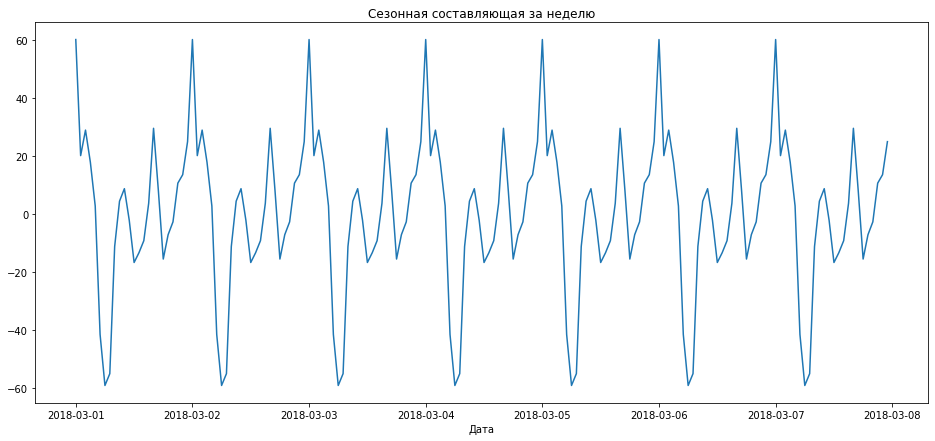

In [24]:
sns.lineplot(data=decomposed.seasonal['2018-03-01':'2018-03-07'])\
.set(title='Сезонная составляющая за неделю',
     xlabel='Дата',
     ylabel='');

Суточная сезонность.

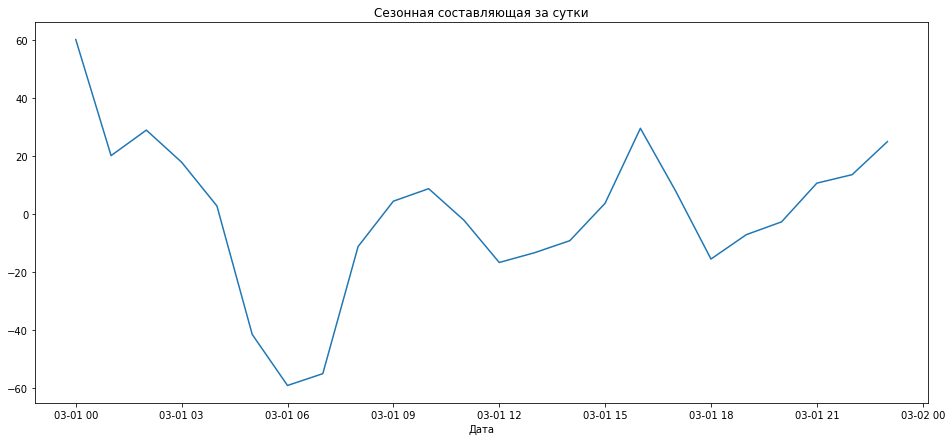

In [25]:
sns.lineplot(data=decomposed.seasonal['2018-03-01':'2018-03-01'])\
.set(title='Сезонная составляющая за сутки',
     xlabel='Дата',
     ylabel='');

Увеличение количества заказов начинается после шести утра, после двенадцати дня и после восемнадцати часов.

**Вывод**

Анализ данных показал, тренд заказов такси показывает рост. Отметили нестационарность временног ряда. Выявлена суточная сезонность. 

## Обучение моделей

Вычислиям и добавляем скользящее среднее как признак 'rolling_mean'. В функцию make_features() добавляем новый аргумент rolling_mean_size, который задаст ширину окна. Текущее значение ряда для расчёта скользящего среднего применять нельзя.

In [26]:
def make_features(data, max_lag, rolling_mean_size):
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    data['hour'] = data.index.hour
    
    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['num_orders'].shift(lag)

    data['rolling_mean'] = data['num_orders'].shift().rolling(rolling_mean_size).mean()
    data = data.dropna()
make_features(taxi, 24, 100)


In [27]:
taxi = taxi.dropna() # удаление пропусков

In [28]:
taxi.head()

,num_orders,rolling_mean,std,day,dayofweek,hour,lag_1,lag_2,lag_3,lag_4,...,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-05 04:00:00,34,56.46,34.419724,5,0,4,51.0,32.0,176.0,86.0,...,30.0,30.0,41.0,19.0,39.0,39.0,12.0,11.0,22.0,27.0
2018-03-05 05:00:00,16,55.56,34.681156,5,0,5,34.0,51.0,32.0,176.0,...,56.0,30.0,30.0,41.0,19.0,39.0,39.0,12.0,11.0,22.0
2018-03-05 06:00:00,3,54.87,35.142773,5,0,6,16.0,34.0,51.0,32.0,...,58.0,56.0,30.0,30.0,41.0,19.0,39.0,39.0,12.0,11.0
2018-03-05 07:00:00,14,54.19,35.043141,5,0,7,3.0,16.0,34.0,51.0,...,64.0,58.0,56.0,30.0,30.0,41.0,19.0,39.0,39.0,12.0
2018-03-05 08:00:00,31,53.67,35.222173,5,0,8,14.0,3.0,16.0,34.0,...,51.0,64.0,58.0,56.0,30.0,30.0,41.0,19.0,39.0,39.0


Функция train_test_split() из модуля sklearn.model_selection по умолчанию перемешивает данные. Поэтому укажем аргумент shuffle=False, чтобы разделить данные корректно.

In [29]:
train, test = train_test_split(taxi, shuffle=False, test_size=0.1) 

Выведем минимальные и максимальные значения индексов выборок, чтобы убедиться в корректности деления.

In [30]:
print(train.index.min(), train.index.max())
print(test.index.min(), test.index.max())

2018-03-05 04:00:00 2018-08-13 23:00:00
2018-08-14 00:00:00 2018-08-31 23:00:00


In [31]:
X_train = train.drop(['num_orders'], axis=1)
y_train = train['num_orders']
X_test = test.drop(['num_orders'], axis=1)
y_test = test['num_orders']

In [32]:
results = pd.DataFrame(columns=['model', 'rmse', 'fit_time', 'pred_time'])

Создадим функцию обучения модели с подбором гиперпараметров, временем обучения и предсказания, оценкой метрикой

In [33]:
ts_cv = TimeSeriesSplit(n_splits = 3)

In [34]:
def model(estimator, param_grid, X_train, y_train, X_test, y_test):
    model = GridSearchCV(estimator=estimator,
                         param_grid=param_grid,
                         n_jobs=-1,
                         cv=ts_cv,
                         scoring='neg_root_mean_squared_error')

    model.fit(X_train, y_train)
    # замеряем rmse на кросс-валидации
    model.best_score_
    rmse = round(np.mean(-model.best_score_))
    # получаем лучшую модель 
    best_model = model.best_estimator_
    print(best_model)
    # замеряем время обучения (в секундах)
    start = time()
    best_model.fit(X_train, y_train)
    end = time()
    fit_time = end - start
    # замеряем время предсказания (в секундах)
    start = time()
    pred_time = best_model.predict(X_train)
    end = time()
    pred_time = end - start
    return best_model, rmse, fit_time, pred_time

In [35]:
best_model_rf, rmse_rf, fit_time_rf, pred_time_rf = model(RandomForestRegressor(random_state=42),
                                              {'n_estimators':[50, 150, 250], 'max_depth':[10, 15, 20]},
                                              X_train, y_train, X_test, y_test)
results.loc[0] = ['RandomForestRegressor', rmse_rf, fit_time_rf, pred_time_rf]
results

RandomForestRegressor(max_depth=15, n_estimators=150, random_state=42)


,model,rmse,fit_time,pred_time
0,RandomForestRegressor,26,9.491179,0.10316


In [36]:
best_model_cbr, rmse_cbr, fit_time_cbr, pred_time_cbr = model(CatBoostRegressor(verbose=100, random_state=42),
                                              {'learning_rate':[0.01, 0.1], 'iterations':[50, 100, 250]},
                                              X_train, y_train, X_test, y_test)
results.loc[1] = ['CatBoostRegressor', rmse_cbr, fit_time_cbr, pred_time_cbr]
results

0:	learn: 29.0847237	total: 51.8ms	remaining: 2.54s
49:	learn: 24.2385934	total: 212ms	remaining: 0us
0:	learn: 32.1537777	total: 5.99ms	remaining: 293ms
49:	learn: 26.6748538	total: 204ms	remaining: 0us
0:	learn: 33.7300629	total: 6.58ms	remaining: 323ms
49:	learn: 27.9458049	total: 245ms	remaining: 0us
0:	learn: 27.9598448	total: 4.19ms	remaining: 205ms
49:	learn: 14.7683537	total: 190ms	remaining: 0us
0:	learn: 30.7896734	total: 4.52ms	remaining: 221ms
49:	learn: 17.2375317	total: 199ms	remaining: 0us
0:	learn: 32.2675237	total: 4.95ms	remaining: 243ms
49:	learn: 18.7851197	total: 221ms	remaining: 0us
0:	learn: 29.0847237	total: 3.85ms	remaining: 381ms
99:	learn: 21.2036078	total: 335ms	remaining: 0us
0:	learn: 32.1537777	total: 4.69ms	remaining: 465ms
99:	learn: 23.4439409	total: 419ms	remaining: 0us
0:	learn: 33.7300629	total: 5.51ms	remaining: 545ms
99:	learn: 24.6712111	total: 454ms	remaining: 0us
0:	learn: 27.9598448	total: 3.74ms	remaining: 370ms
99:	learn: 11.4158893	total: 3

,model,rmse,fit_time,pred_time
0,RandomForestRegressor,26,9.491179,0.103160
1,CatBoostRegressor,26,1.975866,0.003061


In [37]:
best_model_lgbm, rmse_lgbm, fit_time_lgbm, pred_time_lgbm = model(LGBMRegressor(verbose=100, random_state=42),
                                              {'n_estimators':[25, 50, 100], 'learning_rate':[0.1, 0.5, 0.75]},
                                              X_train, y_train, X_test, y_test)
results.loc[2] = ['LGBMRegressor', rmse_lgbm, fit_time_lgbm, pred_time_lgbm]
results

[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.007245
[LightGBM] [Debug] init for col-wise cost 0.003628 seconds, init for row-wise cost 0.104766 seconds
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.195354 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3344
[LightGBM] [Info] Number of data points in the train set: 971, number of used features: 29
[LightGBM] [Info] Start training from score 57.813594
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 9
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 9
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 9
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 11
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 9
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 9
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 8
[LightGBM] [Debug] Trai

,model,rmse,fit_time,pred_time
0,RandomForestRegressor,26,9.491179,0.103160
1,CatBoostRegressor,26,1.975866,0.003061
2,LGBMRegressor,27,0.896538,0.004795


## Анализ моделей

Проверим лучшую модель на адекватность. Используем в качестве константной модели DummyRegressor.

In [38]:
model_dr = DummyRegressor()

In [39]:
start = time()
model_dr.fit(X_train, y_train)
end = time()
dr_time = end - start
dr_time

0.0006380081176757812

In [40]:
# замеряем время предсказания (в секундах)
start = time()
pred_train_dr = model_dr.predict(X_test)
end = time()
dr_pred_time = end - start
dr_pred_time

0.00030994415283203125

In [41]:
rmse_dr = mean_squared_error(y_test, pred_train_dr) ** 0.5
rmse_dr

84.80942472748956

In [42]:
results.loc[3] = ['DummyRegressor', rmse_dr, dr_time, dr_pred_time]
results

,model,rmse,fit_time,pred_time
0,RandomForestRegressor,26,9.491179,0.103160
1,CatBoostRegressor,26,1.975866,0.003061
2,LGBMRegressor,27,0.896538,0.004795
3,DummyRegressor,84.809425,0.000638,0.000310


Лучшая модель по времени обучения и предсказания LGBMRegressor. Качество модели по метрике RMSE близки у трех(всех) моделей LGBMRegressor, CatBoostRegressor, RandomForestRegressor и равны 27,26,26 соотвественно. Определим лучшими моделями LGBMRegressor и CatBoostRegressor, которые также прошли проверку на адекватность, сравнив качество их предсказаний с качеством модели DummyRegressor, которая предсказывала бы константу и получила результат гораздо выше rmse = 84,8.

In [43]:
pred_test_lgbm = best_model_lgbm.predict(X_test)
rmse_test_lgbm = mean_squared_error(y_test, pred_test_lgbm) ** 0.5
rmse_test_lgbm

40.77595682726577

In [44]:
pred_test_cbr = best_model_cbr.predict(X_test)
rmse_test_cbr = mean_squared_error(y_test, pred_test_cbr) ** 0.5
rmse_test_cbr

42.02586890116274

rmse тестовой выборки лучшей модели = 40,8 Значение метрики RMSE на тестовой выборке должно быть не больше 48 по условиям заказчика, значит рекомендуем модель LGBMRegressor.

In [45]:
pred_test_lgbm_series = pd.Series(pred_test_lgbm, index=y_test.index)

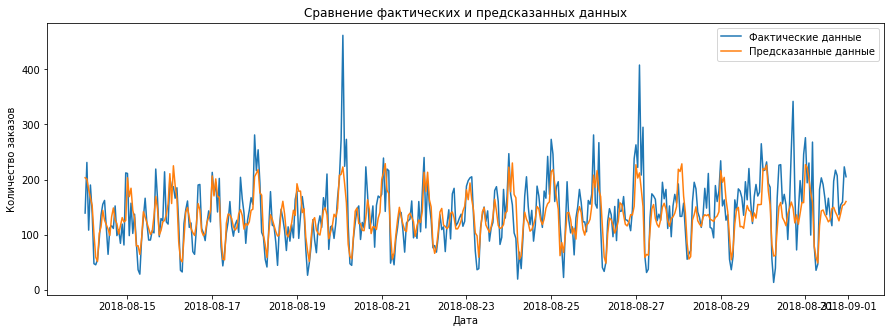

In [46]:
plt.figure(figsize=(15, 5))
sns.lineplot(y=y_test, x=y_test.index)
sns.lineplot(y=pred_test_lgbm_series, x=pred_test_lgbm_series.index)\
.set(title='Сравнение фактических и предсказанных данных',
     xlabel='Дата',
     ylabel='Количество заказов')
plt.legend(['Фактические данные','Предсказанные данные']);

График предсказаний в целом угадывает направление движения количества заказов такси, но хуже справляется на пиках и спадах.

## Общий вывод

В ходе работы подготовили данные (загрузили данные, ресемплировали по одному часу по условиям заказчика), провели анализ данных и выявили тренд заказов такси показывает рост, отметили нестационарность временног ряда, выявлена суточная сезонность. Далее добавили признаков, получили скользящее среднее.

Обучены три модели RandomForestRegressor, CatBoostRegressor, LightGBMRegressor. Проведен анализ моделей качество предсказания, время обучения и время предсказания. Качество лучшей модели LightGBMRegressor проверено на адекватность и имеет результат тестирования на тестовой выборке лучше, чем результат констатной модели (DummyRegressor). Лучшая модель LightGBMRegressor на тестовой выборке имеет качество предсказания = 40,8, а качество предсказания "глупой" модель = 84,8, а также значение метрики RMSE на тестовой выборке не больше 48 (п условию заказчика)

Модель, подходящая условиям заказчика, LGBMRegressor.